In [18]:
import matplotlib.pyplot as plt
import numpy as np

In [19]:
SYNC_WORD = 0x7CD215D8
IDLE_WORD = 0x7A89C197

In [20]:
FSK_DEVIATION_HZ = 4500

In [21]:
BIT1_SIGN = -1
BIT0_SIGN = +1

1010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010101010100111110011010010000101011101100001111010100010011100000110010111011110101000100111000001100101110111101010001001110000011001011101111010100010011100000110010111011110101000100111000001100101110111101010001001110000011001011101111010100010011100000110010111011110101000100111000001100101110111101010001001110000011001011101111010100010011100000110010111011110101000100111000001100101110111101010001001110000011001011100110000

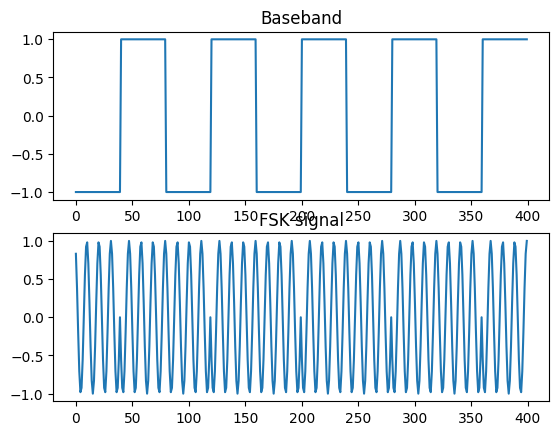

In [24]:
def word_to_bits(word: int) -> list[int]:
    bits_7 = ''
    for char in word:
        bit7 = format(ord(char),'07b') 
        # currently its msb first so 
        bits_7+=bit7[::-1]  
        # on air its lsb first thats why we reverse 
    return bits_7


def calculate_bch(bits21):
    # bits21: string of 21 bits (flag + 20 data)
    poly = "11101101001"          # x^10+x^9+x^8+x^6+x^5+x^3+1
    work = bits21 + "0000000000"  # add 10 zeros at the end

    for i in range(21):
        if work[i] == "1":
            # XOR the next 11 bits with the polynomial
            new = ""
            for j in range(11):
                if work[i + j] == poly[j]:
                    new = new + "0"
                else:
                    new = new + "1"
            work = work[:i] + new + work[i + 11:]

    return work[21:]              # the last 10 bits = BCH
    

def add_bch_code(bit_20,type_mess = True):
    bit_21 = ('1' if type_mess else '0')+bit_20
    bit_10_bch = calculate_bch(bit_21)
    # added the 1 as the flag bit for mess else 0 for addr 
    return bit_21+bit_10_bch


def add_parity_bit(bit_31):
    parity_bit = str(bit_31.count('1')%2)
    bit_32 = bit_31 +parity_bit  
    # bit_32 = 1 codeword 
    return bit_32

def pocsag_tx(mess,addr):
    mess_bits = word_to_bits(mess)
    bits_20 = []
    for i in range(0, len(mess_bits), 20):
        chunk = mess_bits[i:i+20]
        chunk = chunk + '0' * (20 - len(chunk))   # pad the last chunk
        bits_20.append(chunk)
    mess_code_word = []
    for bit_20 in bits_20:
        mess_code_word.append(add_parity_bit(add_bch_code(bit_20)))

    addr_bits = format(int(addr),'021b')
    addr_bit18 = addr_bits[:18]
    frame_number = int(addr_bits[-3::],2)
    addr_bit20 = addr_bit18+'11'
    # 11 is the function bit which is for pointing that the message coming is intenteded to be 
    # alpha nukeirc 

    addr_bit_31 = add_bch_code(addr_bit20,type_mess=False)
    addr_code_word = add_parity_bit(addr_bit_31)
    

    idle_code_word = format(IDLE_WORD,'032b')

    batches = []
    
    batch = [idle_code_word]*16
    # each batch has 16 codeword , and each frame has 2 codeword so , 
    # each batch has 8 frame 

    batch[frame_number*2] = addr_code_word
    mess_code_word_index = 0
    for i in range(frame_number*2+1,len(batch)):
        if mess_code_word_index > len(mess_code_word)-1:
            break 
        batch[i] = mess_code_word[mess_code_word_index]
        mess_code_word_index+=1
    batches.append(batch)

    # more batch needed check 
    while mess_code_word_index<len(mess_code_word):
        batch = [idle_code_word]*16
        for i in range(16):
            # as we now have alreayd added addr in the first batch 
            if mess_code_word_index>=len(mess_code_word):
                break 
            batch[i] = mess_code_word[mess_code_word_index]
            mess_code_word_index+=1
        batches.append(batch)

    # added a sync word to every batch 
    for batch_idx in range(0,len(batches)):
        batches[batch_idx] = [format(SYNC_WORD,'032b')]+batches[batch_idx]

    # now each batch has 17 codeword total 

    preamble = '10'*288
    # 576 is common bit length of a preamble so 10 multiple by 576/2 
    

    bitstream = preamble 

    for batch in batches:
        for codeword in batch:
            bitstream += codeword

    print(bitstream)

    # now the modulation of the bits 
    baud = 1200
    fs = 48000

    sample_per_bit = int(fs/baud)

    
    mapped = {'0':[BIT0_SIGN]*sample_per_bit,'1':[BIT1_SIGN]*sample_per_bit}
    signal = []
    for bit in bitstream:
        signal.extend(mapped[bit])

    I = []
    Q = []
    phase = 0 # initailly 
    for bit in signal:
        phase += 2*np.pi*bit*FSK_DEVIATION_HZ / fs
        # this moves the angle over tine , 2pi meabs a full cycle  and FSK_DEVIATION_HZ is the 
        # cycle per second and /fs gives cycles per sample 
        I.append(np.cos(phase))
        Q.append(np.sin(phase))

    iq = np.zeros(len(I) * 2, dtype=np.float32)
    iq[::2] = I
    iq[1::2] = Q
    iq.tofile('my_pocsag.iq')

    n = sample_per_bit*10 
    # showing only first 10 bit signal 
    
    plt.subplot(2, 1, 1)
    plt.plot(signal[:n])
    plt.title("Baseband")

    plt.subplot(2, 1, 2)
    plt.plot(I[:n])
    plt.title("FSK signal")

    plt.show()


pocsag_tx('kemchobhai',798406)
        
    
    
        